<a href="https://colab.research.google.com/github/satya-screator/PENGAPLIKASIAN-PCA-Untuk-KONVERSI-GAMBAR/blob/main/PENGAPLIKASIAN_PCA_Untuk_KONVERSI_GAMBAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Silakan upload gambar Anda:


Saving 2504130146.jpg to 2504130146.jpg
✓ '2504130146.jpg' berhasil diupload



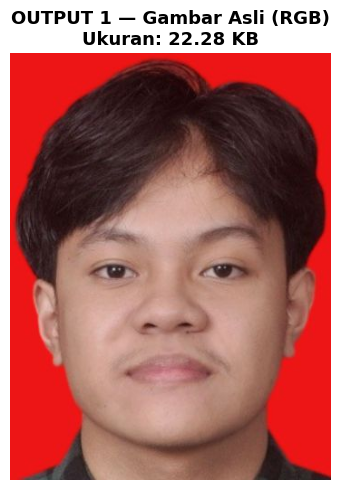

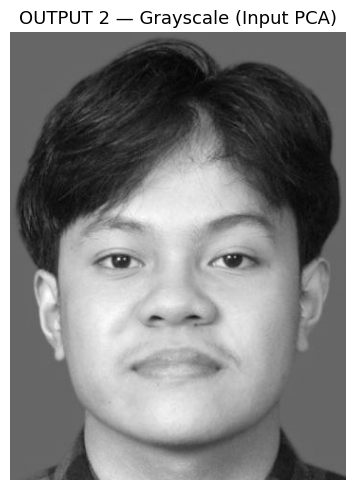

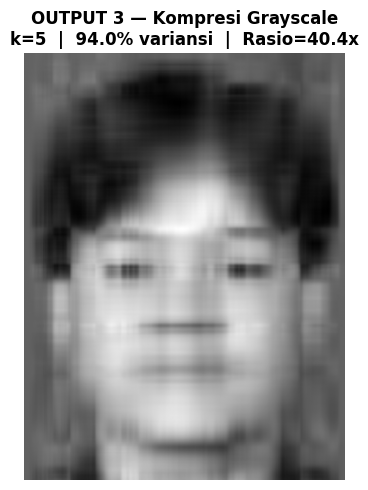

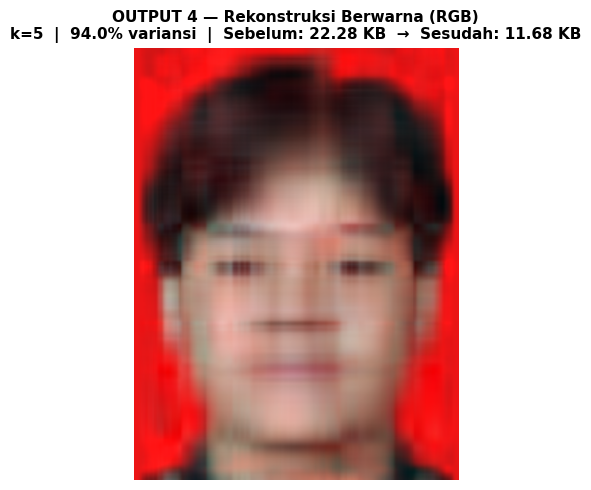

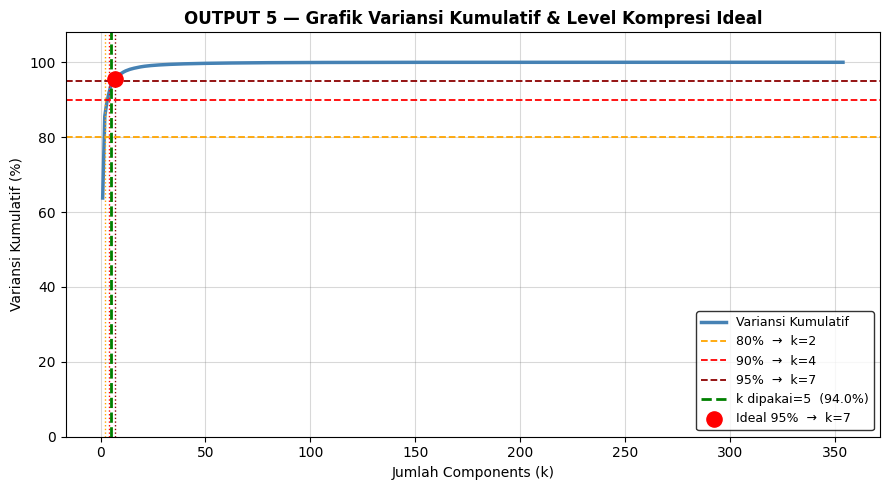


  RINGKASAN KOMPRESI PCA
  k digunakan       : 5
  k ideal (95%)     : 7
  Variansi tercapai : 94.00%
  Rasio kompresi    : 40.41x
  Dimensi gambar    : 354 x 472
  Ukuran SEBELUM    : 22.28 KB
  Ukuran SESUDAH    : 11.68 KB
─────────────────────────────────────────────────────────────────
  MATRIKS EIGENVALUE (Top 10)
─────────────────────────────────────────────────────────────────
  [   462375.62    158078.52     27559.58     17769.72     15921.19 ]
  [     6163.62      4870.18      4601.56      4077.62      2610.05 ]

✓ Proses Selesai.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from google.colab import files
import io, os

# ─────────────────────────────────────────────
# UPLOAD GAMBAR
# ─────────────────────────────────────────────
print("Silakan upload gambar Anda:")
uploaded   = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]
print(f"✓ '{IMAGE_PATH}' berhasil diupload\n")

COMPRESSION_LEVEL = 5   # ← ubah sesuka Anda

# ─────────────────────────────────────────────
# FUNGSI
# ─────────────────────────────────────────────

def load_image(path):
    img  = Image.open(path).convert("RGB")
    rgb  = np.array(img, dtype=np.float64)
    gray = 0.299*rgb[:,:,0] + 0.587*rgb[:,:,1] + 0.114*rgb[:,:,2]
    return rgb, gray

def hitung_pca(matriks):
    rata2   = np.mean(matriks, axis=0)
    dp      = matriks - rata2
    kov     = np.cov(dp, rowvar=False)
    ev, vec = np.linalg.eigh(kov)
    idx     = np.argsort(ev)[::-1]
    return ev[idx], vec[:,idx], rata2, dp

def kompresi_channel(dp, vec, rata2, k):
    komp  = vec[:, :k]
    rekon = (dp @ komp) @ komp.T + rata2
    return np.clip(rekon, 0, 255)

def kompresi_rgb(rgb, k):
    hasil = np.zeros_like(rgb)
    for i in range(3):
        ch      = rgb[:,:,i]
        r2      = np.mean(ch, axis=0)
        dp      = ch - r2
        kov     = np.cov(dp, rowvar=False)
        ev, vec = np.linalg.eigh(kov)
        idx     = np.argsort(ev)[::-1]
        vec     = vec[:, idx]
        komp    = vec[:, :k]
        rekon   = (dp @ komp) @ komp.T + r2
        hasil[:,:,i] = np.clip(rekon, 0, 255)
    return hasil.astype(np.uint8)

def format_bytes(b):
    if b < 1024:      return f"{b} B"
    elif b < 1024**2: return f"{b/1024:.2f} KB"
    else:             return f"{b/1024**2:.2f} MB"

# ─────────────────────────────────────────────
# PROSES PCA
# ─────────────────────────────────────────────
img_rgb, img_gray  = load_image(IMAGE_PATH)
ev, vec, rata2, dp = hitung_pca(img_gray)
img_gray_rekon     = kompresi_channel(dp, vec, rata2, COMPRESSION_LEVEL)
img_color_rekon    = kompresi_rgb(img_rgb, COMPRESSION_LEVEL)

total    = np.sum(ev)
cumvar   = np.cumsum(ev) / total * 100
variansi = cumvar[COMPRESSION_LEVEL - 1]
k_ideal  = int(np.searchsorted(cumvar, 95)) + 1
H, W     = img_gray.shape
rasio    = (H * W) / (COMPRESSION_LEVEL * (H + W + 1))

# Ukuran byte
byte_asli   = os.path.getsize(IMAGE_PATH)
buf         = io.BytesIO()
Image.fromarray(img_color_rekon).save(buf, format="JPEG")
byte_kompr  = buf.tell()

# ═══════════════════════════════════════════════════════
# OUTPUT 1 — GAMBAR ASLI
# ═══════════════════════════════════════════════════════
plt.figure(figsize=(7,5), facecolor='white')
plt.imshow(img_rgb.astype(np.uint8))
plt.title(f"OUTPUT 1 — Gambar Asli (RGB)\nUkuran: {format_bytes(byte_asli)}",
          fontsize=13, fontweight="bold", color='black')
plt.axis("off")
plt.tight_layout()
plt.savefig("1_gambar_asli.png", dpi=150, bbox_inches="tight", facecolor='white')
plt.show()

# ═══════════════════════════════════════════════════════
# OUTPUT 2 — GRAYSCALE
# ═══════════════════════════════════════════════════════
plt.figure(figsize=(7,5), facecolor='white')
plt.imshow(img_gray, cmap="gray")
plt.title("OUTPUT 2 — Grayscale (Input PCA)", fontsize=13, color='black')
plt.axis("off")
plt.tight_layout()
plt.savefig("2_grayscale.png", dpi=150, bbox_inches="tight", facecolor='white')
plt.show()

# ═══════════════════════════════════════════════════════
# OUTPUT 3 — KOMPRESI GRAYSCALE
# ═══════════════════════════════════════════════════════
plt.figure(figsize=(7,5), facecolor='white')
plt.imshow(img_gray_rekon, cmap="gray")
plt.title(
    f"OUTPUT 3 — Kompresi Grayscale\n"
    f"k={COMPRESSION_LEVEL}  |  {variansi:.1f}% variansi  |  Rasio={rasio:.1f}x",
    fontsize=12, fontweight="bold", color='black')
plt.axis("off")
plt.tight_layout()
plt.savefig("3_kompresi_grayscale.png", dpi=150, bbox_inches="tight", facecolor='white')
plt.show()

# ═══════════════════════════════════════════════════════
# OUTPUT 4 — REKONSTRUKSI BERWARNA
# ═══════════════════════════════════════════════════════
plt.figure(figsize=(7,5), facecolor='white')
plt.imshow(img_color_rekon)
plt.title(
    f"OUTPUT 4 — Rekonstruksi Berwarna (RGB)\n"
    f"k={COMPRESSION_LEVEL}  |  {variansi:.1f}% variansi  |  "
    f"Sebelum: {format_bytes(byte_asli)}  →  Sesudah: {format_bytes(byte_kompr)}",
    fontsize=11, fontweight="bold", color='black')
plt.axis("off")
plt.tight_layout()
plt.savefig("4_rekonstruksi_warna.png", dpi=150, bbox_inches="tight", facecolor='white')
plt.show()

# ═══════════════════════════════════════════════════════
# OUTPUT 5 — GRAFIK VARIANSI KUMULATIF
# ═══════════════════════════════════════════════════════
plt.figure(figsize=(9,5), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

xi = np.arange(1, len(cumvar)+1)
plt.plot(xi, cumvar, color="steelblue", lw=2.5, label="Variansi Kumulatif")

for thr, col, ls in [(80,"orange","--"),(90,"red","--"),(95,"darkred","--")]:
    ki = int(np.searchsorted(cumvar, thr)) + 1
    plt.axhline(y=thr, color=col, ls=ls, lw=1.3, label=f"{thr}%  →  k={ki}")
    plt.axvline(x=ki,  color=col, ls=":",  lw=1.0)

plt.axvline(x=COMPRESSION_LEVEL, color="green", ls="--", lw=2,
            label=f"k dipakai={COMPRESSION_LEVEL}  ({variansi:.1f}%)")
plt.scatter([k_ideal],[cumvar[k_ideal-1]], color="red",
            s=120, zorder=5, label=f"Ideal 95%  →  k={k_ideal}")

plt.title("OUTPUT 5 — Grafik Variansi Kumulatif & Level Kompresi Ideal",
          fontsize=12, fontweight="bold", color='black')
plt.xlabel("Jumlah Components (k)", fontsize=10, color='black')
plt.ylabel("Variansi Kumulatif (%)", fontsize=10, color='black')
plt.tick_params(axis='both', colors='black')
plt.ylim(0, 108)
plt.legend(fontsize=9, loc="lower right", facecolor='white', edgecolor='black', labelcolor='black')
plt.grid(True, alpha=0.3, color='gray')
plt.tight_layout()
plt.savefig("5_grafik_variansi.png", dpi=150, bbox_inches="tight", facecolor='white')
plt.show()

# ─────────────────────────────────────────────
# RINGKASAN TERMINAL
# ─────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  RINGKASAN KOMPRESI PCA")
print(f"{'='*65}")
print(f"  k digunakan       : {COMPRESSION_LEVEL}")
print(f"  k ideal (95%)     : {k_ideal}")
print(f"  Variansi tercapai : {variansi:.2f}%")
print(f"  Rasio kompresi    : {rasio:.2f}x")
print(f"  Dimensi gambar    : {W} x {H}")
print(f"  Ukuran SEBELUM    : {format_bytes(byte_asli)}")
print(f"  Ukuran SESUDAH    : {format_bytes(byte_kompr)}")
print(f"{'─'*65}")
print(f"  MATRIKS EIGENVALUE (Top 10)")
print(f"{'─'*65}")
# Menampilkan Eigenvalue dalam format matriks 2x5
for i in range(0, 10, 5):
    row = [f"{ev[j]:11.2f}" for j in range(i, i+5)]
    print("  [ " + "  ".join(row) + " ]")
print(f"{'='*65}")
print("\n✓ Proses Selesai.")